# SpMV kernel version comparison

Compares the three multicore SpMV kernels on the same set of matrices:

| version | kernel | bench | csv |
|---|---|---|---|
| `multicore` | `run_spmv` | `spmv` | `bench_results_spmv_128_fp16.csv` |
| `multicube` | `run_spmv_multi_cube` | `spmv_multi_cube` | `bench_results_spmv_multi_cube_128_fp16.csv` |
| `spmv_v2` | `run_spmv_v2` | `spmv_v2` | `bench_results_spmv_v2_128_fp16.csv` |

Generate the data with:
```bash
make -f Makefile.spmv.mk profile_fp16_spmv_versions
```
By default the CSVs are written to the current directory (`TCUSCAN_BENCHMARK_REPORT_PATH`
defaults to `.`), which is what `benchmarks_dir` below points at. Set both to a
different directory if you want to keep runs separate.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

benchmarks_dir = "../.."

# (glob pattern, version label). The patterns are mutually exclusive:
# *spmv_128* does not match spmv_multi_cube_128 nor spmv_v2_128.
version_globs = [
    ("*spmv_128*.csv", "multicore"),
    ("*spmv_multi_cube_128*.csv", "multicube"),
    ("*spmv_v2_128*.csv", "spmv_v2"),
]

dfs = []
for pattern, version in version_globs:
    files = glob(join(benchmarks_dir, pattern))
    if not files:
        print(f"WARNING: no files match {pattern}")
        continue
    df = pd.concat(map(pd.read_csv, files))
    df["version"] = version
    dfs.append(df)

grand_df = pd.concat(dfs)
grand_df = grand_df.sort_values(by=["nnz", "version"])
grand_df.head(20)

,benchname,operator,dtype,nnz,time_us,version
2,conf5_4-8x8-05,spmv_128,fp16,1916928,703.06,multicore
3,conf5_4-8x8-10,spmv_128,fp16,1916928,739.46,multicore
8,conf5_4-8x8-05,spmv_128,fp16,1916928,723.05,multicore
9,conf5_4-8x8-10,spmv_128,fp16,1916928,700.83,multicore
14,conf5_4-8x8-05,spmv_128,fp16,1916928,719.55,multicore
15,conf5_4-8x8-10,spmv_128,fp16,1916928,731.68,multicore
2,conf5_4-8x8-05,spmv_multi_cube_128,fp16,1916928,698.95,multicube
3,conf5_4-8x8-10,spmv_multi_cube_128,fp16,1916928,693.59,multicube
2,conf5_4-8x8-05,spmv_v2_128,fp16,1916928,654.66,spmv_v2
3,conf5_4-8x8-10,spmv_v2_128,fp16,1916928,721.88,spmv_v2


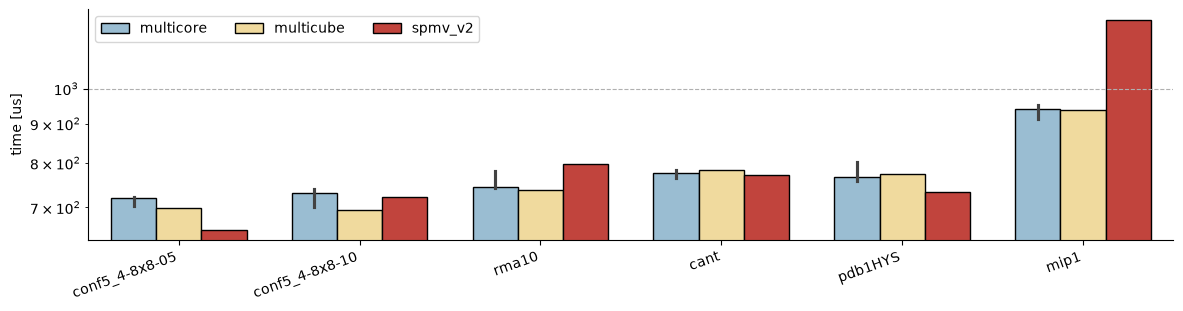

In [5]:
# Per-matrix bar chart: time [us], one bar per version.
palette = ["#91bfdb", "#fee090", "#d73027"]

plt.figure(figsize=(14, 3))
ax = sns.barplot(
    data=grand_df,
    x="benchname",
    y="time_us",
    hue="version",
    hue_order=["multicore", "multicube", "spmv_v2"],
    edgecolor="black",
    palette=palette,
    estimator="median",
    width=0.75,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(linestyle="--", axis="y")
plt.legend(loc="upper left", ncol=3)
plt.xticks(rotation=20, ha="right")
plt.xlabel("")
plt.ylabel("time [us]")
plt.yscale("log")
plt.savefig("spmv_versions_comparison.pdf", bbox_inches="tight")

In [6]:
# Speedup of each version relative to the multicore baseline, per matrix.
med = grand_df.groupby(["benchname", "version"])["time_us"].median().unstack()
speedup = med.div(med["multicore"], axis=0)
speedup = speedup.rename(columns=lambda c: f"{c}_x_over_multicore")
speedup.sort_values("multicube_x_over_multicore")

version,multicore_x_over_multicore,multicube_x_over_multicore,spmv_v2_x_over_multicore
benchname,,,
conf5_4-8x8-10,1.0,0.947942,0.986606
conf5_4-8x8-05,1.0,0.971371,0.909819
rma10,1.0,0.990876,1.070641
mip1,1.0,0.998554,1.307962
pdb1HYS,1.0,1.007727,0.954499
cant,1.0,1.009571,0.995395


## Random-matrix sweeps

The real-matrix plots above use `profile_sparse_matrices.py`. This section adds the
**random-matrix** sweeps produced by `profile_random_matrices.py`, which vary `nnz`
across a range of densities and two nonzero distributions (Uniform / PowerLaw).

Generate the data with:
```bash
make -f Makefile.spmv.mk profile_fp16_spmv_random     # multicore baseline
make -f Makefile.spmv.mk profile_fp16_spmv_v2_random  # spmv_v2
```
CSVs are written as `random_matrices_{distr}_{operator}_{alpha}_128_{dtype}_{density}.csv`
in `benchmarks_dir`. (There is no `spmv_multi_cube` random target, so only
`multicore` and `spmv_v2` appear here.)


In [ ]:
# --- Random-matrix sweeps (profile_random_matrices.py) ---
# time [us] vs nnz, per SpMV version, faceted by distribution x density.
#
# NOTE: the CSVs written by profile_random_matrices.py currently have a broken
# alpha/density column (a missing f-string prefix writes the literal
# "f{density}"), which also makes the row shorter than the header. So we do NOT
# trust the header: we derive version / distribution / density from the file
# name and read only the reliable fields (size = nnz, and the last field =
# time_us). This is also tolerant of partially-written files while a benchmark
# run is still in progress.
import os
import re
from glob import glob

import pandas as pd

rand_pattern = re.compile(
    r"random_matrices_(?P<distr>\w+?)_"
    r"(?P<operator>spmv(?:_v2)?)_[\d.]+_128_"  # operator_alpha_s
    r"(?P<dtype>\w+)_(?P<density>[\d.]+)\.csv$"
)

rand_rows = []
for path in sorted(glob(join(benchmarks_dir, "random_matrices_*_128_*.csv"))):
    m = rand_pattern.search(os.path.basename(path))
    if not m:
        continue
    version = "spmv_v2" if m["operator"] == "spmv_v2" else "multicore"
    for line in open(path, encoding="UTF-8"):
        fields = line.strip().split(",")
        if not fields or fields[0] == "operator" or len(fields) < 3:
            continue  # header / blank / truncated line
        try:
            nnz = int(fields[2])
            time_us = float(fields[-1])
        except ValueError:
            continue  # partially-written row
        rand_rows.append(
            {
                "version": version,
                "distr": m["distr"],
                "density": float(m["density"]),
                "nnz": nnz,
                "time_us": time_us,
            }
        )

if not rand_rows:
    print("WARNING: no random-matrix data found (benchmarks may still be running)")
else:
    rand_df = pd.DataFrame(rand_rows).sort_values(["distr", "density", "nnz"])
    g = sns.relplot(
        data=rand_df,
        x="nnz",
        y="time_us",
        hue="version",
        hue_order=["multicore", "spmv_v2"],
        style="version",
        markers=True,
        kind="line",
        estimator="median",
        col="density",
        row="distr",
        palette=["#91bfdb", "#d73027"],
        facet_kws={"sharey": False},
        height=2.8,
        aspect=1.4,
    )
    g.set(xscale="log", yscale="log")
    for ax in g.axes.flat:
        ax.grid(linestyle="--")
    g.set_axis_labels("nnz", "time [us]")
    g.savefig("spmv_versions_random_comparison.pdf", bbox_inches="tight")
    display(rand_df.head(20))
